Add your import statements and the database connection statements in the below code block

Database file path = '/course/data/CSE-578/dinofunworld.db'

In [74]:
#your code here
import sqlite3
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from pandas.plotting import parallel_coordinates, scatter_matrix
from scipy import signal
from datetime import datetime as dt
%matplotlib inline

# Connect to the database
db_filename = "dinofunworld.db"
connect = sqlite3.connect(db_filename)
cursor = connect.cursor()

# Explore database structure
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables_names = cursor.fetchall()
print(tables_names)
for name in tables_names:
    cursor.execute(f"SELECT * FROM {name[0]}")
    table_cols = [description[0] for description in cursor.description]
    print(table_cols)

[('checkin',), ('attraction',), ('sequences',)]
['index', 'visitorID', 'timestamp', 'attraction', 'duration', 'type']
['index', 'AttractionID', 'Name', 'Region', 'Category', 'type']
['index', 'visitorID', 'sequence']


**Question 1:** 

What is the most popular attraction to visit in the park?

**Note:** Your output should be the name of the attraction. Please print your output in the cell below.

In [76]:
### TEST FUNCTION: test_question1
# DO NOT REMOVE THE LINE ABOVE
# your code here
query = """
SELECT Name 
FROM attraction 
WHERE attraction.AttractionID = (
    SELECT attraction
    FROM checkin
    GROUP BY attraction
    HAVING count(attraction) = (
        SELECT Max(x)
        FROM(
            SELECT count(attraction) as x
            FROM checkin
            GROUP BY attraction
        )
    )
)
"""
cursor.execute(query)
name = cursor.fetchone()[0]
print(name)

Atmosfear


**Question 2:** 

What ride (note that not all attractions are rides) has the second longest average visit time?

**Note:** Your output should be the name of the ride. Please print your output in the cell below.


In [78]:
### TEST FUNCTION: test_question2
# DO NOT REMOVE THE LINE ABOVE
# your code here

cursor.execute("SELECT Name FROM attraction WHERE Category LIKE '%ride%'")
rides = cursor.fetchall()

ride_time = {}
for ride in rides:
    ride_time[ride[0]] = 0

ride_count_and_total_time = dict()
for ride in rides:
    ride_count_and_total_time[ride[0]] = (0,0)
query = """
SELECT Name, duration
FROM attraction, checkin
WHERE Category LIKE '%ride%' and attraction.AttractionID = checkin.attraction and checkin.type = 'actual'
"""
cursor.execute(query)
ride_duration = cursor.fetchall()
for category, duration in ride_duration:
    if duration is not None and dt.strptime(duration, "%H:%M:%S").time():
        time = dt.strptime(duration, "%H:%M:%S").time()
        duration_seconds = time.hour * 3600 + time.minute * 60 + time.second
        ride_count = ride_count_and_total_time[category][0] + 1
        ride_total_time = ride_count_and_total_time[category][1] + duration_seconds
        ride_count_and_total_time[category] = (ride_count, ride_total_time)

rides_averages = {}
for key, value in ride_count_and_total_time.items():
    ride_count = value[0]
    ride_total_time = value[1]
    rides_averages[key] = ride_total_time/ride_count

sorted_avg_list = [value for value in rides_averages.values()]
sorted_avg_list.sort()
second_avg_time = sorted_avg_list[-2]

for key, value in rides_averages.items():
    if value == second_avg_time:
        print(key)

Flight of the Swingodon


**Question 3:** 

Which Fast Food offering in the park has the fewest visitors?

**Note:** Your output should be the name of the fast food offering. Please print your output in the cell below.

In [80]:
### TEST FUNCTION: test_question3
# DO NOT REMOVE THE LINE ABOVE
# your code here

# query = """
# SELECT Name 
# FROM attraction 
# WHERE attraction.AttractionID = (
#     SELECT attraction
#     FROM checkin
#     GROUP BY attraction
#     HAVING count(attraction) = (
#         SELECT Min(x)
#         FROM(
#             SELECT count(checkin.attraction) as x
#             FROM checkin, attraction
#             WHERE attraction.Category LIKE '%Food%' and attraction.AttractionID = checkin.attraction
#             GROUP BY checkin.attraction
#         )
#     )
# )
# """

query = """
SELECT Name
FROM attraction, checkin
WHERE attraction.Category LIKE '%Food%' and attraction.AttractionID = checkin.attraction
GROUP BY Name
ORDER BY count(Name) ASC
"""
cursor.execute(query)
seq = cursor.fetchone()[0]
print(seq)

Theresaur Food Stop


**Question 4 :** 

Make a Pie Chart of the visits to Thrill Ride attractions.

**Note:** 
* For this question, display the pie chart in the notebook and print the data used to create the pie chart as a list of lists (ex: [['Ride 1', 10], ['Ride 2', 100], ...])
* The pie chart must have the below mentioned parameters,
    * labels
    * title named '**Visits to Thrill Ride attractions**'
    * label with one decimal value inside wedges
    * set aspect ratio of the plot to 'equal'.
* The plot must not have the following parameters,
    * legend
    * do not set figure size
    * do not set font size or font-weight for titles and labels


[['TerrorSaur', 14415], ['Wendisaurus Chase', 15577], ['Firefall', 16024], ['Flight of the Swingodon', 16093], ['Auvilotops Express', 18694], ['Wrightiraptor Mountain', 18700], ['Galactosaurus Rage', 18717], ['Keimosaurus Big Spin', 18792], ['Atmosfear', 27747]]


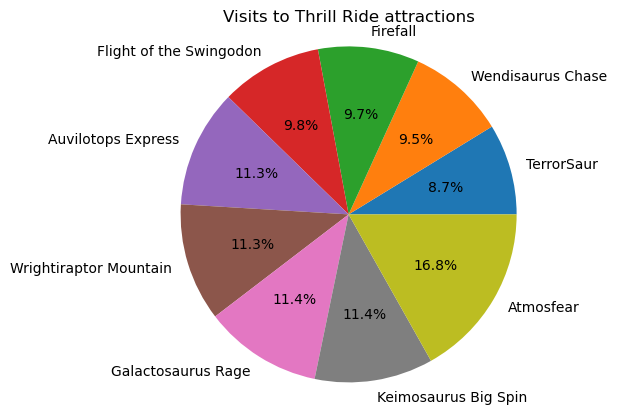

In [82]:
### TEST FUNCTION: test_question1
# DO NOT REMOVE OR MODIFY THE ABOVE LINE
# your code here
query = """
SELECT attraction.Name, count(checkin.attraction)
FROM checkin, attraction
WHERE attraction.AttractionID = checkin.attraction AND attraction.Category LIKE '%Thrill Rides%'
GROUP BY checkin.attraction
ORDER BY count(checkin.attraction)
"""
cursor.execute(query)
visitor_count = cursor.fetchall()
visitors_list = [[r, v] for (r, v) in visitor_count]
print(visitors_list)
visitors_df = pd.DataFrame.from_records(visitor_count, columns = ['Ride Name', 'Visitors Count'])

plt.pie(visitors_df['Visitors Count'], labels=visitors_df['Ride Name'], autopct='%1.1f%%')
plt.title('Visits to Thrill Ride attractions')
plt.axis('equal')
plt.show()

**Question 5 :** 

Make a bar chart of total visits to food stalls.

**Note:** 
* Please query attractions with category equal to "Food" and order by number of visits.
* For this question, display the bar chart in the notebook and print the data used to create the bar chart as a list of lists (ex: [['Stall 1', 10], ['Stall 2', 50], ...])
* The bar chart should be a **vertical bar plot** and must have the specified parameters listed below,
  * Set x-axis to food stalls, labeling each food stall with names rotated at a 45-degree angle and right horizontal alignment. Set y-axis to number of visits.
  * x-label ('**Food Stalls**') and y-label ('**Number of Visits**')
  * title named '**Total Visits to Food Stalls**'
* The plot must not have the following parameters,
    * legend
    * do not set figure size
    * do not set font size or font-weight for titles and labels


[['Theresaur Food Stop', 1116], ['Paleo Shreckwiches', 1361], ["Shilobite o'Pizza", 1393], ['Krystal Cook Cafe', 1725], ['Granite Slab Pizza', 2810], ['Plaisantly Popped Corn', 2914], ['Permafrosties', 3018], ['EberTrex Fries', 3018], ['Smoky Wood BBQ', 3037], ['Chensational Sweets', 3049], ['Floral Funnels', 3083], ['Ice Age Cones', 3228]]


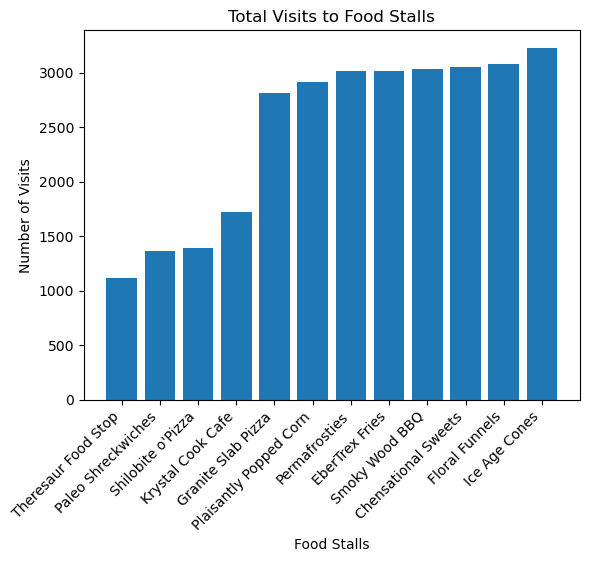

In [84]:
### TEST FUNCTION: test_question2
# DO NOT REMOVE OR MODIFY THE ABOVE LINE
# your code here
query = """
SELECT attraction.Name, count(checkin.attraction) as Visitors
FROM checkin, attraction
WHERE attraction.AttractionID = checkin.attraction AND attraction.Category LIKE '%Food%'
GROUP BY checkin.attraction
ORDER BY Visitors ASC
"""
cursor.execute(query)
visitor_count = cursor.fetchall()
visitors_list = [[r, v] for (r, v) in visitor_count]
print(visitors_list)
visitors_df = pd.DataFrame.from_records(visitor_count, columns = ['Ride Name', 'Visitors Count'])
# fig, ax = plt.subplots()
# ax.bar(visitors_df['Ride Name'], visitors_df['Visitors Count'])
# ax.set_xlabel('Food Stalls')
# ax.set_ylabel('Number of Visits')
# ax.set_xticks(visitors_df['Ride Name'])
# ax.set_xticklabels(visitors_df['Ride Name'], rotation=45, ha='right')
plt.bar(visitors_df['Ride Name'], visitors_df['Visitors Count'])
plt.xlabel('Food Stalls')
plt.ylabel('Number of Visits')
plt.title('Total Visits to Food Stalls')
plt.xticks(rotation=45, ha='right')
plt.show()

**Question 6 :** 

Make a line chart of attendance at Atmosfear every five minutes.

**Note:** 
* For this question, use data from the table "sequences". You can assume that all activity sequences are aligned by time (i.e., the first node of all sequences occurred at the same time) and are of the same length.
* You only need to consider the first 16 hours of records in the sequences, which is considered the open hours of the park in one day. Specifically, because an activity sequence from the "sequences" table was updated/recorded every 5 minutes, you need to extract the first 192 items (16h * 60m / 5m = 192).
* Display the line chart in the notebook and print the data used to create the chart as a list of lists or tuple lists 
    * The first item in the list is irrelevant, but you can put in some meaningful information and it should be integer.The second item is the count of visits at that moment. For example, your output should look like this (in Python syntax; not relevant to the correct answer): [ (0, 0), (1, 7), (2, 3), …, (190, 4), (191, 5) ].
* The line chart must have the specified parameters listed below,
  * Set x-axis to the first element in your output list and y-axis to the second item in the list (number of visits)  
  * x-label ('**Time in minutes**') and y-label ('**Number of visits**')
  * title named '**Attendance at Atmosfear every 5 minutes**'
* The plot must not have the following parameters,
    * legend
    * do not set figure size
    * do not set font size or font-weight for titles and labels

[(0, 0), (5, 0), (10, 9), (15, 19), (20, 49), (25, 62), (30, 46), (35, 44), (40, 33), (45, 75), (50, 81), (55, 98), (60, 75), (65, 89), (70, 80), (75, 85), (80, 52), (85, 82), (90, 80), (95, 103), (100, 108), (105, 93), (110, 68), (115, 90), (120, 89), (125, 117), (130, 108), (135, 81), (140, 89), (145, 94), (150, 87), (155, 85), (160, 82), (165, 97), (170, 100), (175, 137), (180, 142), (185, 134), (190, 109), (195, 138), (200, 142), (205, 157), (210, 164), (215, 176), (220, 78), (225, 73), (230, 62), (235, 77), (240, 73), (245, 99), (250, 118), (255, 109), (260, 108), (265, 106), (270, 100), (275, 134), (280, 90), (285, 83), (290, 78), (295, 96), (300, 95), (305, 102), (310, 133), (315, 97), (320, 110), (325, 121), (330, 134), (335, 102), (340, 101), (345, 114), (350, 103), (355, 123), (360, 87), (365, 111), (370, 140), (375, 129), (380, 103), (385, 94), (390, 53), (395, 43), (400, 53), (405, 76), (410, 78), (415, 53), (420, 73), (425, 82), (430, 104), (435, 91), (440, 84), (445, 89),

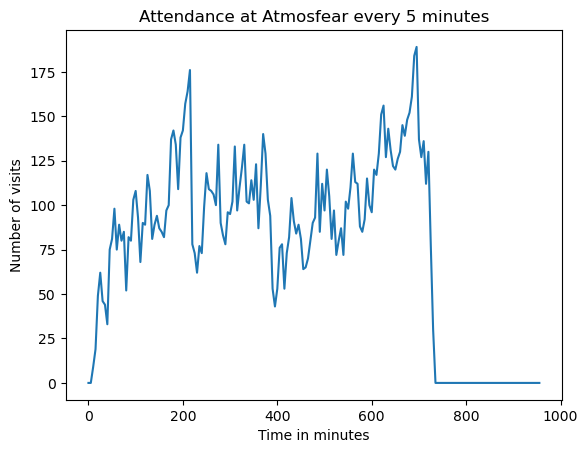

In [86]:
### TEST FUNCTION: test_question3
# DO NOT REMOVE OR MODIFY THE ABOVE LINE
# your code here
attraction_id = cursor.execute("SELECT AttractionID FROM attraction WHERE Name LIKE '%Atmosfear%'").fetchone()[0]
cursor.execute("SELECT sequence FROM sequences")
sequences = cursor.fetchall()

# extract the first 192 attractions ids from each sequence string
sequences_pruned = np.asarray([tup[0].split('-')[:192] for tup in sequences])
# count the total number of matching attraction id at each time-point in the sequence
total_visits_sequence = np.sum(sequences_pruned == str(attraction_id), axis = 0)
time_range = list(range(0, len(total_visits_sequence)*5, 5))
time_visits_list = zip(time_range, total_visits_sequence.tolist())
print(list(time_visits_list))

x = time_range
y = total_visits_sequence
plt.plot(x,y)
plt.xlabel("Time in minutes")
plt.ylabel("Number of visits")
plt.title("Attendance at Atmosfear every 5 minutes")
plt.show()

**Question 7:**

Make a box plot of total visits to rides in the Kiddie Rides category.

**Note:** 
* The to-be-printed data list must be ordered by AttractionID (a field in the table "attraction").
* For this question, display the box plot in the notebook and print the number of visits to each ride as a list (ex: [3, 4, 5, 6, ...])
* The boxplot chart must have the specified parameters listed below,
  * Set x-axis to Attraction and y-axis to number of visits to each ride.   
  * x-label ('**Attraction**') and y-label ('**Visitor Count**')
  * title named '**Total visits to rides in the Kiddie Rides category**'
* The plot must not have the following parameters,
    * legend
    * do not set figure size
    * do not set font size or font-weight for titles and labels

[3597, 3759, 4062, 3640, 3747, 3963, 3747, 3925, 3922, 4022, 3877]


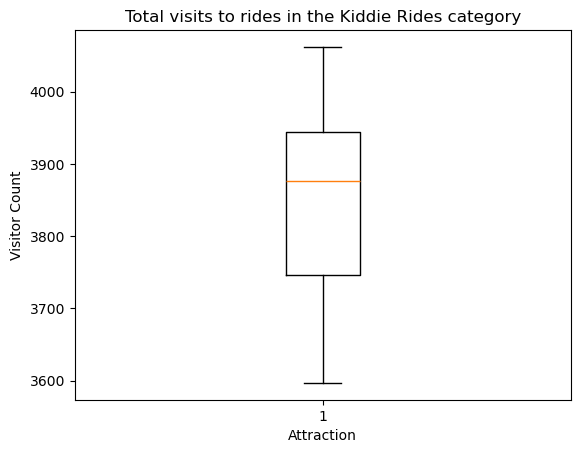

In [88]:
### TEST FUNCTION: test_question4
# DO NOT REMOVE OR MODIFY THE ABOVE LINE
# your code here
query = """
SELECT attraction.AttractionID, count(checkin.attraction)
FROM checkin, attraction
WHERE attraction.AttractionID = checkin.attraction AND attraction.Category LIKE '%Kiddie Rides%'
GROUP BY checkin.attraction
"""
cursor.execute(query)
ids_and_visitors = cursor.fetchall()
# ids = [id[0] for id in ids]
ids = []
visitors = []

for (i, v) in ids_and_visitors:
    ids.append(i)
    visitors.append(v)
print(visitors)

plt.boxplot(visitors)
plt.xlabel("Attraction")
plt.ylabel("Visitor Count")
plt.title("Total visits to rides in the Kiddie Rides category")
plt.show()

### **Question 8:**
Create a distance matrix suitable for use in hierarchical clustering of the checkin sequences of the 5 specified visitors.

Your distance function should count the number of dissimilarities in the sequences without considering any other factors.

**Note** 
* The distance matrix should be reported as a dictionary of dictionaries (eg. {1: {2:0, 3:0, 4:0}, 2: {1:0, 3:0, ...}, ...}).
* The order of the output is not important.

In [90]:
### TEST FUNCTION: test_question1
# DO NOT REMOVE OR MODIFY THE ABOVE LINE
# your code here
cursor.execute("SELECT visitorID, sequence FROM sequences WHERE visitorID in (165316, 1835254, 296394, 404385, 448990)")
sequence = cursor.fetchall()

dist_matrix = {}
checked = []
for i in range(len(sequence)):
    sub_dict = {}
    main_id_key = sequence[i][0]
    for j in range(len(sequence)):
        sub_id_key = sequence[j][0]
        if main_id_key != sub_id_key:
            sequence1_pruned = np.asarray([int(k) for k in sequence[i][1].split('-')])
            sequence2_pruned = np.asarray([int(k) for k in sequence[j][1].split('-')])
            sub_dict[sub_id_key] = np.sum(abs(np.subtract(sequence1_pruned, sequence2_pruned)) != 0).tolist()
            dist_matrix[main_id_key] = sub_dict
print(dist_matrix)

{165316: {296394: 318, 404385: 329, 448990: 318, 1835254: 336}, 296394: {165316: 318, 404385: 303, 448990: 0, 1835254: 282}, 404385: {165316: 329, 296394: 303, 448990: 303, 1835254: 298}, 448990: {165316: 318, 296394: 0, 404385: 303, 1835254: 282}, 1835254: {165316: 336, 296394: 282, 404385: 298, 448990: 282}}


### **Question 9:**  
Create and display a Parallel Coordinate Plot displaying the minimum, maximum and average attendance for each ride in the park.

For this question, display a Parallel Coordinate Plot in the notebook and print the data used to create a Parallel Coordinate Plot as a dictionary of dictionaries (eg: {  'Ride1' : {min : 1, max : 3, avg : 2 }, 'Ride2' :{ min : 1, max : 3, avg : 2 } ... })

**Note:** 
* Not all attractions are rides.
* The output should be a dictionary and the order of the output is not important.
* Use the parallel coordinates function from the **pandas library** to generate the graph.
* The Parallel Coordinate plot must have the below mentioned parameters,
    * legend and it should be outside the plot.
    * y-label ('**Attendance**')
    * title named '**Ride Attendance - Minimum, Maximum, Average**'
* The plot must not have the following parameters,
    * do not set figure size
    * do not set font size or font-weight for titles and labels

{'Wrightiraptor Mountain': {'min': 1, 'max': 158, 'avg': 52.75}, 'Galactosaurus Rage': {'min': 1, 'max': 261, 'avg': 56.63715277777778}, 'Auvilotops Express': {'min': 1, 'max': 640, 'avg': 118.97916666666667}, 'TerrorSaur': {'min': 2, 'max': 424, 'avg': 248.09375}, 'Wendisaurus Chase': {'min': 5, 'max': 491, 'avg': 233.6875}, 'Keimosaurus Big Spin': {'min': 2, 'max': 206, 'avg': 64.39756944444444}, 'Firefall': {'min': 1, 'max': 576, 'avg': 233.46875}, 'Atmosfear': {'min': 5, 'max': 335, 'avg': 126.359375}, 'North Line': {'min': 1, 'max': 166, 'avg': 45.06944444444444}, 'Jeredactyl Jump': {'min': 1, 'max': 112, 'avg': 21.66840277777778}, 'Sauroma Bumpers': {'min': 1, 'max': 148, 'avg': 23.866319444444443}, 'Flying TyrAndrienkos': {'min': 1, 'max': 98, 'avg': 19.76215277777778}, 'Cyndisaurus Asteroid': {'min': 1, 'max': 72, 'avg': 12.947916666666666}, 'Beelzebufo': {'min': 1, 'max': 93, 'avg': 13.869791666666666}, 'Enchanted Toadstools': {'min': 1, 'max': 77, 'avg': 12.864583333333334}, 

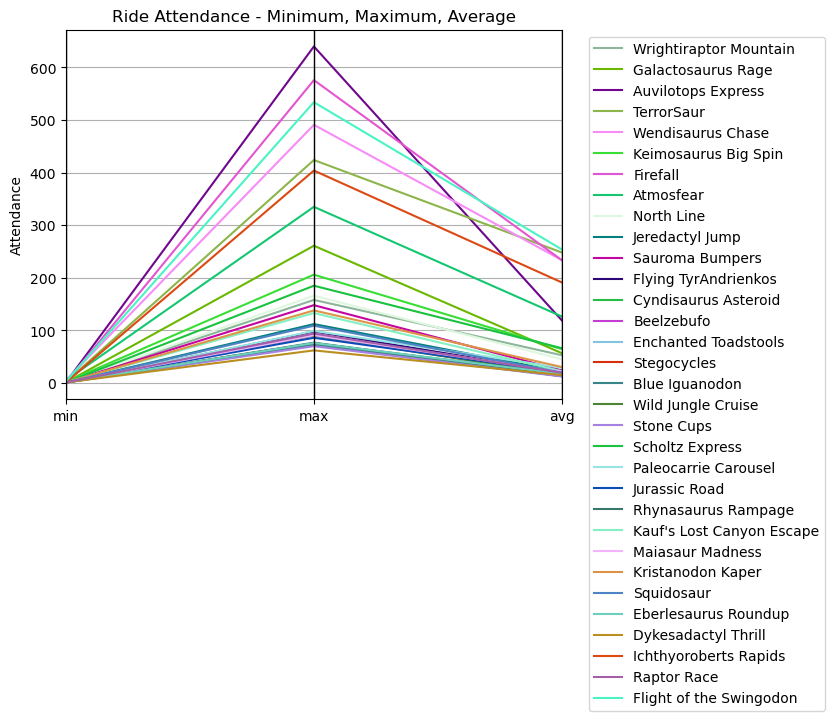

In [92]:
### TEST FUNCTION: test_question2
# DO NOT REMOVE OR MODIFY THE ABOVE LINE
# your code here
rides = cursor.execute("SELECT AttractionID, Name FROM attraction WHERE Category LIKE '%Ride%'").fetchall()
sequences = cursor.execute("SELECT sequence FROM sequences").fetchall()
sequences = np.asarray([tup[0].split('-') for tup in sequences])
attendance = {}
for (idx, name) in rides:
    matches = np.sum(sequences == str(idx), axis = 0)
    minimum = np.min(np.where(matches != 0, matches, np.inf))
    maximum = np.max(matches)
    average = np.mean(matches)
    metrics = {'min': int(minimum), 'max': int(maximum), 'avg': float(average)}
    attendance[name] = metrics
print(attendance)
names_df = pd.DataFrame({'rides': attendance.keys()})
metrics_df = pd.DataFrame(attendance.values())
attendance_df = pd.concat([names_df,metrics_df], axis = 1)
parallel_coordinates(attendance_df, 'rides')
plt.legend(bbox_to_anchor=(1.04, 1.0), loc='upper left')
plt.ylabel("Attendance")
plt.title("Ride Attendance - Minimum, Maximum, Average")
plt.show()

### **Question 10:**
Create and display a Scatterplot Matrix displaying the minimum, maximum and average attendance for each ride in the park.


**Note:** 
* Print the output values of Question 2 as the same data will be used for Scatterplot.
* The output should be a dictionary (eg: {  'Ride1' : {min : 1, max : 3, avg : 2 }, 'Ride2' :{ min : 1, max : 3, avg : 2 } ... }) and the order of the output is not important.
* This is a different view into the same data as the previous part. Use the scatter plot matrix function from the **pandas library** to generate the graph.
* While you work on these plots, consider the different things that each chart says about the data.
* The Scatterplot must have the below mentioned parameters,
    * title named ' **Scatterplot Matrix - Minimum, Maximum, Average Attendance** '
* The plot must not have the following parameters,
    * legend
    * do not set figure size
    * do not set font size or font-weight for titles and labels

{'Wrightiraptor Mountain': {'min': 1, 'max': 158, 'avg': 52.75}, 'Galactosaurus Rage': {'min': 1, 'max': 261, 'avg': 56.63715277777778}, 'Auvilotops Express': {'min': 1, 'max': 640, 'avg': 118.97916666666667}, 'TerrorSaur': {'min': 2, 'max': 424, 'avg': 248.09375}, 'Wendisaurus Chase': {'min': 5, 'max': 491, 'avg': 233.6875}, 'Keimosaurus Big Spin': {'min': 2, 'max': 206, 'avg': 64.39756944444444}, 'Firefall': {'min': 1, 'max': 576, 'avg': 233.46875}, 'Atmosfear': {'min': 5, 'max': 335, 'avg': 126.359375}, 'North Line': {'min': 1, 'max': 166, 'avg': 45.06944444444444}, 'Jeredactyl Jump': {'min': 1, 'max': 112, 'avg': 21.66840277777778}, 'Sauroma Bumpers': {'min': 1, 'max': 148, 'avg': 23.866319444444443}, 'Flying TyrAndrienkos': {'min': 1, 'max': 98, 'avg': 19.76215277777778}, 'Cyndisaurus Asteroid': {'min': 1, 'max': 72, 'avg': 12.947916666666666}, 'Beelzebufo': {'min': 1, 'max': 93, 'avg': 13.869791666666666}, 'Enchanted Toadstools': {'min': 1, 'max': 77, 'avg': 12.864583333333334}, 

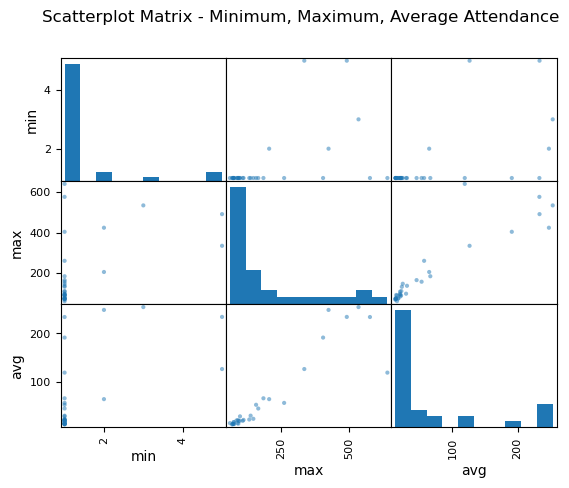

In [94]:
### TEST FUNCTION: test_question3
# DO NOT REMOVE OR MODIFY THE ABOVE LINE
# your code here
print(attendance)
scatter_matrix(attendance_df)
plt.suptitle("Scatterplot Matrix - Minimum, Maximum, Average Attendance")
plt.show()

### **Question 11**:
Create and display a control chart showing attendance at the ride 'Atmosfear' over the data provided. In the control chart, display the attendance, the mean attendance, and bands for one and two standard deviations away from the average.

**Note:** 
* For this question, display the control chart in the notebook and print the mean attendance and standard deviation values as a list. 
For example: [mean, standard_deviation]
* Create a single Control chart that displays the mean, standard deviation, and attendance, adhering to the specified line style and color as outlined below.
    * Mean: 'g-'
    * +2 STD and -2 STD: 'r-'
    * +STD and -STD: 'y-'
    * Attendance: 'b-'
* The Control Chart should also have the below mentioned parameters,
    * legend that displays the mean and standard deviation adhering to the specified line and color. Note: Legend should be outside the plot.
    * title named '**Control Chart of attendance at Atmosfear**'
    * x-label ('**Time in minutes**') and y-label ('**Attendance**')
* The plot must not have the following parameters,
    * do not set figure size
    * do not set font size or font-weight for titles and labels


[126.359375, 73.63511071604992]


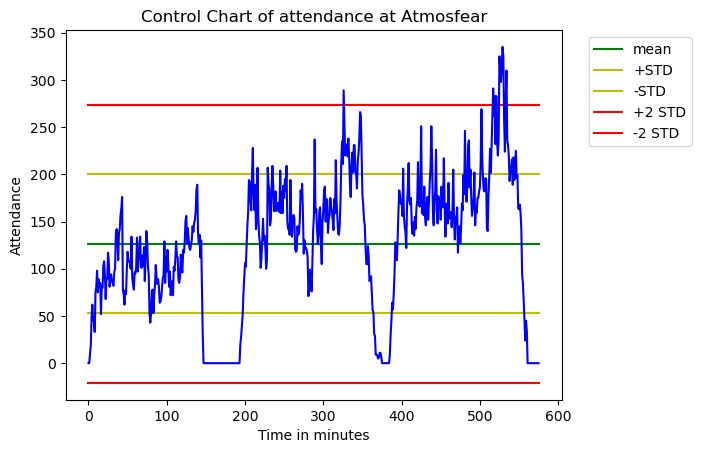

In [96]:
### TEST FUNCTION: test_question1
# DO NOT REMOVE OR MODIFY THE ABOVE LINE
# your code here
attraction_id = cursor.execute("SELECT AttractionID FROM attraction WHERE Name LIKE '%Atmosfear%'").fetchone()
sequences = cursor.execute("SELECT sequence FROM sequences").fetchall()
sequences = np.asarray([tup[0].split('-') for tup in sequences])
attendance = np.sum(sequences == str(attraction_id[0]), axis = 0)
mean = float(np.nanmean(attendance))
std = float(np.nanstd(attendance))
print([mean,std])

plt.plot([0,len(attendance)], [mean, mean], 'g-')
plt.plot([0,len(attendance)], [mean+std, mean+std], 'y-')
plt.plot([0,len(attendance)], [mean-std, mean-std], 'y-')
plt.plot([0,len(attendance)], [mean+2*std, mean+2*std], 'r-')
plt.plot([0,len(attendance)], [mean-2*std, mean-2*std], 'r-')
plt.plot(range(len(attendance)), attendance, 'b-')
plt.legend(['mean','+STD','-STD', '+2 STD', '-2 STD'], bbox_to_anchor=(1.04, 1.0), loc='upper left')
plt.title('Control Chart of attendance at Atmosfear')
plt.xlabel('Time in minutes')
plt.ylabel('Attendance')
plt.show()

### **Question 12**:
Create and display a moving average chart of the attendance at 'Atmosfear' over the data provided. Use a window size of 50 for this moving average.

**Note:** 
* The Moving Average Chart should have the below mentioned parameters,
    * set mode to 'same' while performing convolution
    * title named '**Moving Average Chart of attendance at Atmosfear**'
    * x-label ('**Time in minutes**') and y-label ('**Attendance**')
* The plot must not have the following parameters,
    * legend
    * do not set figure size
    * do not set font size or font-weight for titles and labels


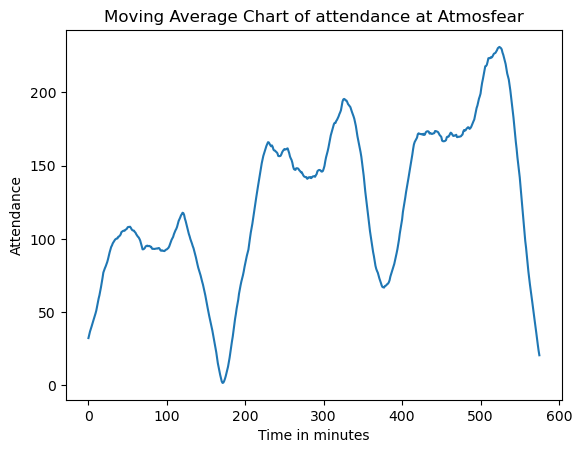

In [98]:
### TEST FUNCTION: test_question2
# DO NOT REMOVE OR MODIFY THE ABOVE LINE
# your code here
attraction_id = cursor.execute("SELECT AttractionID FROM attraction WHERE Name LIKE '%Atmosfear%'").fetchone()
sequences = cursor.execute("SELECT sequence FROM sequences").fetchall()
sequences = np.asarray([tup[0].split('-') for tup in sequences])
attendance = np.sum(sequences == str(attraction_id[0]), axis = 0)

window_size = 50
moving_average = np.convolve(attendance, np.ones(window_size)/window_size, 'same')
plt.plot(moving_average)
plt.title('Moving Average Chart of attendance at Atmosfear')
plt.xlabel('Time in minutes')
plt.ylabel('Attendance')
plt.show()

### **Question 13**:
Create and display an exponentially-weighted moving average chart of the attendance at 'Atmosfear' over the data provided. Again, use a window size of 50 for this weighted moving average.

**Note:** 
* The Weighted Moving Average Chart should have the below mentioned parameters,
    * title named '**Exponentially Weighted Moving Average Chart of the attendance at Atmosfear**'  
    * x-label ('**Time in minutes**') and y-label ('**Attendance**')
* The plot must not have the following parameters,
    * legend
    * do not set figure size
    * do not set font size or font-weight for titles and labels


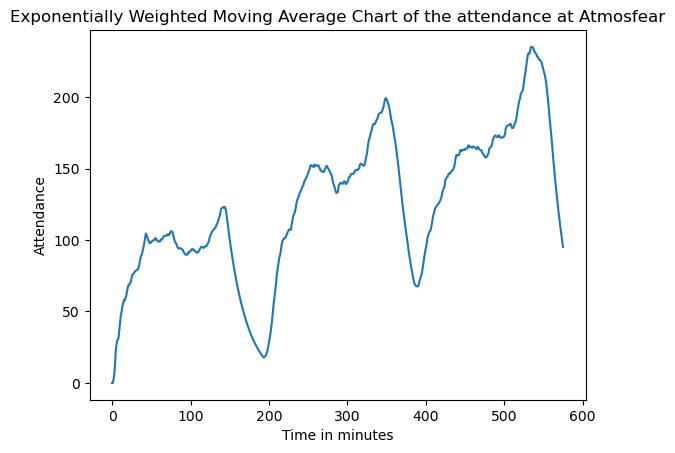

In [100]:
### TEST FUNCTION: test_question3
# DO NOT REMOVE OR MODIFY THE ABOVE LINE
# your code here
attendance_df = pd.DataFrame({'attendance': attendance})
exp_average = attendance_df.ewm(span=50).mean()
plt.plot(exp_average)
plt.title('Exponentially Weighted Moving Average Chart of the attendance at Atmosfear')
plt.xlabel('Time in minutes')
plt.ylabel('Attendance')
plt.show()

Add you import statements and the database connection statements in the below code block

Database file path: /course/data/CSE-578/dinofunworld.db

In [102]:
# import statements here
import sqlite3
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
%matplotlib inline

db_filename = "dinofunworld.db"
connect = sqlite3.connect(db_filename)
cursor = connect.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables_names = cursor.fetchall()
print(tables_names)
for name in tables_names:
    cursor.execute(f"SELECT * FROM {name[0]}")
    table_cols = [description[0] for description in cursor.description]
    print(table_cols)

[('checkin',), ('attraction',), ('sequences',)]
['index', 'visitorID', 'timestamp', 'attraction', 'duration', 'type']
['index', 'AttractionID', 'Name', 'Region', 'Category', 'type']
['index', 'visitorID', 'sequence']


**Question 14:**

Create and display a dendrogram of the trajectories of the 5 visitors specified above. The clustering algorithm used to create the dendrogram should use the average distance between points in a cluster.

**NOTE:**

* You can reuse the distance matrix from Assignment 3.
* Make sure to use the correct clustering algorithm.
* The dendrogram  should have the following parameters:
    * Title should be '**Dendrogram of Trajectories of 5 Visitors to the Park**'
    * xlabel should be '**Visitor ID**' and ylabel should be '**Distance**'.
* The plot must not have the following parameters,
    * do not set figure size
    * do not set font size or font-weight for titles and labels




{165316: {296394: 318, 404385: 329, 448990: 318, 1835254: 336}, 296394: {165316: 318, 404385: 303, 448990: 0, 1835254: 282}, 404385: {165316: 329, 296394: 303, 448990: 303, 1835254: 298}, 448990: {165316: 318, 296394: 0, 404385: 303, 1835254: 282}, 1835254: {165316: 336, 296394: 282, 404385: 298, 448990: 282}}
[[318 329 318 336]
 [318 303   0 282]
 [329 303 303 298]
 [318   0 303 282]
 [336 282 298 282]]


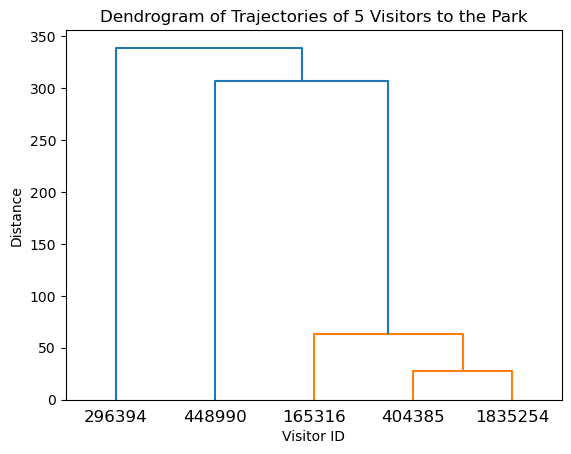

In [104]:
### TEST FUNCTION: test_question1
# DO NOT MODIFY OR REMOVE THE ABOVE LINE
# your code here
cursor.execute("SELECT visitorID, sequence FROM sequences WHERE visitorID in (165316, 1835254, 296394, 404385, 448990)")
sequence = cursor.fetchall()

dist_matrix_dict = {}
dist_matrix = []
ids = []
for i in range(len(sequence)):
    sub_dict = {}
    main_id_key = sequence[i][0]
    ids.append(main_id_key)
    for j in range(len(sequence)):
        sub_id_key = sequence[j][0]
        if main_id_key != sub_id_key:
            sequence1_pruned = np.asarray([int(k) for k in sequence[i][1].split('-')])
            sequence2_pruned = np.asarray([int(k) for k in sequence[j][1].split('-')])
            distance = np.sum(abs(np.subtract(sequence1_pruned, sequence2_pruned)) != 0)
            sub_dict[sub_id_key] = distance
            dist_matrix_dict[main_id_key] = sub_dict
            dist_matrix.append(distance)
print(dist_matrix_dict)
X = np.matrix(dist_matrix).reshape(-1,4)
print(X)
links = linkage(X, method = 'average')
dendrogram(links, labels = ids)
plt.xlabel('Visitor ID')
plt.ylabel('Distance')
plt.title('Dendrogram of Trajectories of 5 Visitors to the Park')
plt.show()